In [1]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_ollama import ChatOllama
from langchain_mcp_adapters.tools import load_mcp_tools
from langchain_community.tools import DuckDuckGoSearchRun

from mcp import ClientSession
from mcp.client.streamable_http import streamablehttp_client
from IPython.display import Image, display

import os

In [2]:
llm = ChatOllama(model="gpt-oss:20b", temperature=0)

In [3]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

def chatbot(state: State):
    return { "messages": [llm_with_tools.invoke(state["messages"])]}

def run(question: str):
    for event in graph.stream({"messages": [{"role": "user", "content": question}]}):
        for val in event.values():
            print("AI: ", val["messages"][-1].content)

async def async_run(question: str):
    response = await graph.ainvoke({
        "messages": [
            {"role": "user", "content": question}
        ]
    })
    
    for message in response["messages"]:
        print(message.pretty_print())
        print()

    return response["messages"][-1].content

In [ ]:
# tavily_token = os.getenv("TAVILY_API_TOKEN")

# mcp_client = streamablehttp_client(f"https://mcp.tavily.com/mcp/?tavilyApiKey={tavily_token}")

# read, write, _  = await mcp_client.__aenter__()

# session = ClientSession(read, write)

# await session.initialize()

# search_tool = await load_mcp_tools(session)

In [4]:
search_tool = DuckDuckGoSearchRun()

In [5]:
tools = [search_tool]
# tools = search_tool

llm_with_tools = llm.bind_tools(tools)
tools_node = ToolNode(tools=tools)

In [6]:
builder = StateGraph(State)
builder.add_node("chatbot", chatbot)
builder.add_node("tools", tools_node)
builder.add_edge(START, "chatbot")
builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)
builder.add_edge("tools", "chatbot")
graph = builder.compile()

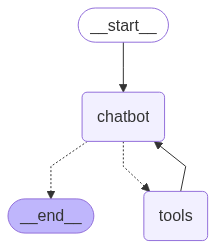

In [7]:
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except:
    pass

In [8]:
question = "What is MXFP4 quantization ?"
resp = await async_run(question)
print(resp)

/home/huo/Workdir/venv/py3gptoss/lib/python3.12/site-packages/langchain_community/utilities/duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:
/home/huo/Workdir/venv/py3gptoss/lib/python3.12/site-packages/langchain_community/utilities/duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:
/home/huo/Workdir/venv/py3gptoss/lib/python3.12/site-packages/langchain_community/utilities/duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:
/home/huo/Workdir/venv/py3gptoss/lib/python3.12/site-packages/langchain_community/utilities/duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as dd

================================ Human Message =================================

What is MXFP4 quantization ?
None

================================== Ai Message ==================================
Tool Calls:
  duckduckgo_search (df51f656-e80b-4f12-8d22-d5ae66e7b2e7)
 Call ID: df51f656-e80b-4f12-8d22-d5ae66e7b2e7
  Args:
    query: MXFP4 quantization
None

================================= Tool Message =================================
Name: duckduckgo_search

Pornhub ist das Zuhause der besten Sex-Videos, bei uns wirst Du immer wieder kommen. Pornhub Deutschland ist die unbestrittene Quelle der wildesten Hardcore Sex-Videos, prallvoll … Breaking news, sport, TV, radio and a whole lot more. The BBC informs, educates and entertains - wherever you are, whatever your age. The best of the BBC, with the latest news and sport headlines, weather, TV & radio highlights and much more from across the whole of BBC Online. Visit BBC for trusted reporting on the latest world and US news, sports, b

In [6]:
# question = "What is MXFP4 quantization ?"
# run(question)

AI:  The maximum number of bits that can be stored in a 10 × 10 × 10 voxel grid, where each voxel can be either 0 or 1, is

\[
10 \times 10 \times 10 = 1000 \text{ bits}.
\]
